# CIFAR-10 Image Classification using CNN

## Objective

The objective of this project is to build a Convolutional Neural Network (CNN) that classifies colour images into one of ten categories from the CIFAR-10 dataset. The model learns visual patterns such as edges, shapes, textures, and object features to identify the correct image class.

## Dataset

The project uses the **CIFAR-10** dataset, available directly through TensorFlow/Keras.

It contains 60,000 colour images of size 32×32 pixels, divided into ten classes:

1. Airplane  
2. Automobile  
3. Bird  
4. Cat  
5. Deer  
6. Dog  
7. Frog  
8. Horse  
9. Ship  
10. Truck  

The dataset has 50,000 training images and 10,000 testing images.

## Data Preprocessing

The dataset was loaded using `keras.datasets.cifar10.load_data()`.

The following preprocessing steps were performed:

1. Displayed sample images to understand the dataset.
2. Converted pixel values from the range 0–255 to the range 0–1.
3. Kept the class labels as numerical values from 0 to 9.
4. Used 20% of the training data as validation data during model training.

## CNN Model Architecture

A Convolutional Neural Network was built using TensorFlow/Keras.

The model contains:

- Convolutional layers to extract visual features from images.
- Batch Normalization layers to stabilize training.
- Max Pooling layers to reduce image dimensions.
- Dropout layers to reduce overfitting.
- Flatten layer to convert feature maps into a single vector.
- Dense layers for final classification.
- Softmax output layer with ten neurons, one for each CIFAR-10 class.

## Model Training

The model was compiled using:

- **Optimizer:** Adam  
- **Loss Function:** Sparse Categorical Crossentropy  
- **Evaluation Metric:** Accuracy  

The model was trained for 15 epochs with a batch size of 64. During training, both training and validation accuracy/loss were monitored.

## Results and Evaluation

The trained model was evaluated using the test dataset.

The following were used to evaluate performance:

- Test accuracy
- Test loss
- Training and validation accuracy graph
- Training and validation loss graph
- Predicted labels compared with actual labels for sample test images

**Final Test Accuracy:** Add the accuracy displayed after running the evaluation cell.

The model successfully learns to classify many images correctly. Some errors may occur between visually similar classes, such as cats and dogs, or automobiles and trucks.

## Conclusion

A CNN model was successfully developed for CIFAR-10 image classification. The project demonstrates how deep learning can be used to recognize objects in colour images.

The model can be improved further by using data augmentation, increasing the number of training epochs, tuning hyperparameters, or applying transfer learning with a pretrained model.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3938s 23us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


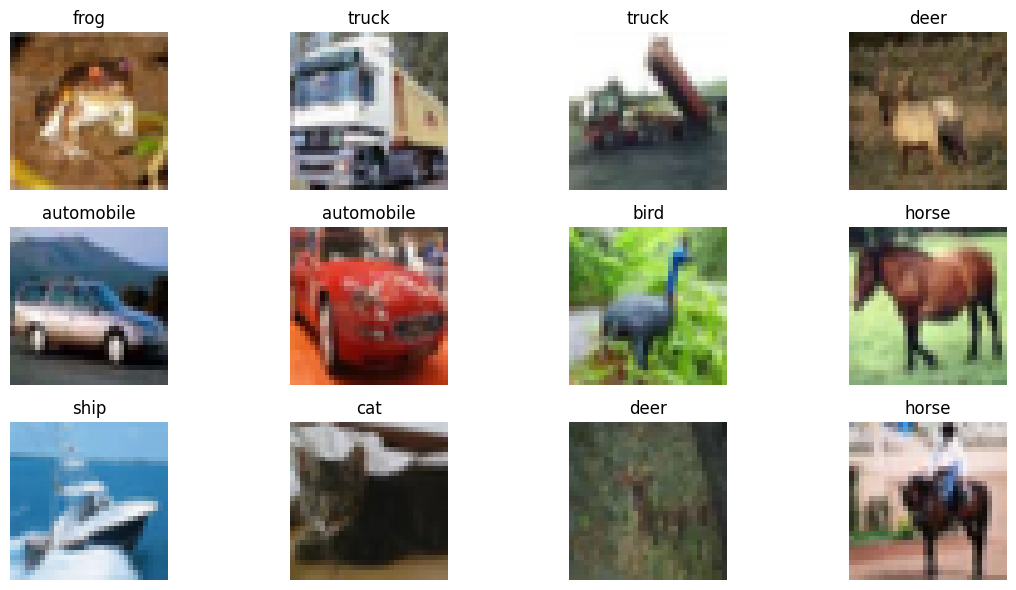

In [3]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [5]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,370 (1.54 MB)

 Trainable params: 403,178 (1.54 MB)

 Non-trainable params: 192 (768.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 391ms/step - accuracy: 0.3150 - loss: 1.8412 - val_accuracy: 0.4653 - val_loss: 1.4824
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 398ms/step - accuracy: 0.5049 - loss: 1.3720 - val_accuracy: 0.4958 - val_loss: 1.4865
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 251s 402ms/step - accuracy: 0.5847 - loss: 1.1797 - val_accuracy: 0.6453 - val_loss: 0.9937
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 398ms/step - accuracy: 0.6331 - loss: 1.0465 - val_accuracy: 0.6084 - val_loss: 1.1304
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 406ms/step - accuracy: 0.6659 - loss: 0.9637 - val_accuracy: 0.6857 - val_loss: 0.8958
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 405ms/step - accuracy: 0.6861 - loss: 0.9062 - val_accuracy: 0.6962 - val_loss: 0.8852
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 395ms/step - accuracy: 0.7005 - loss: 0.8669 - val_accuracy: 0.7200 - val_loss: 0.8125
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 255s 408ms/step - accuracy: 0.7135 -

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.7768 - loss: 0.6511
Test Loss: 0.651068389415741
Test Accuracy: 0.7767999768257141


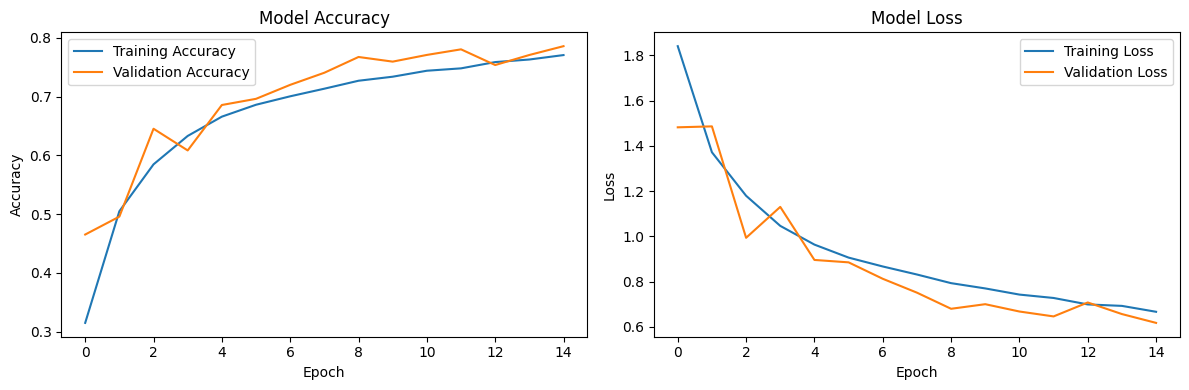

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step


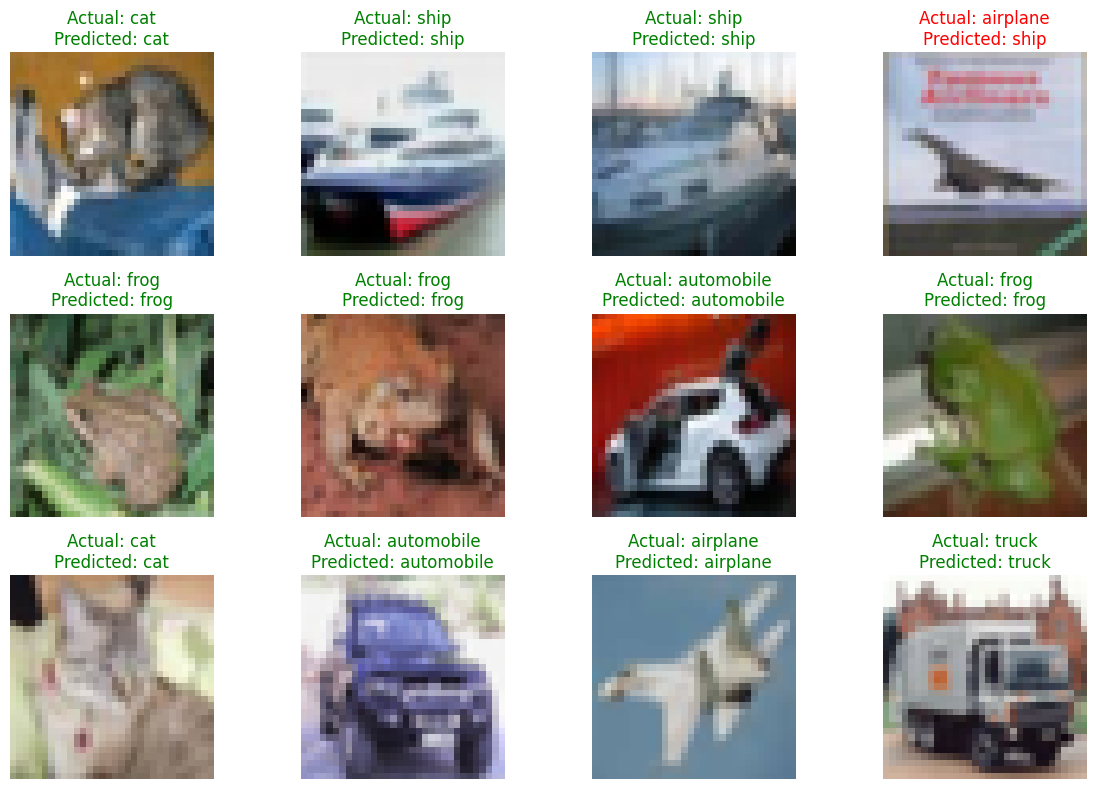

In [9]:
predictions = model.predict(x_test)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])

    predicted_label = class_names[np.argmax(predictions[i])]
    actual_label = class_names[y_test[i][0]]

    color = "green" if predicted_label == actual_label else "red"

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()